# 03 - Modelagem de Previsão de Churn

## Objetivo
Construir e treinar modelos preditivos para identificar clientes com risco de churn:
- Implementar Logistic Regression (modelo com normalização)
- Implementar Random Forest (modelo sem necessidade de normalização)
- Comparar desempenho dos modelos
- Analisar importância das variáveis
- Gerar previsões

## Estrutura:
Este notebook implementa dois modelos diferentes para comparação:
1. **Logistic Regression**: Requer dados escalados, altamente interpretável
2. **Random Forest**: Não requer normalização, robusto e não-paramétrico

## Próximos passos após este notebook:
- Avaliação detalhada com múltiplas métricas (Notebook 04)
- Relatório final com insights estratégicos (Notebook 05)

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Adicionar src/ ao path
sys.path.append(str(Path().resolve().parents[0]))

# Importações padrão
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Machine Learning - Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

# Machine Learning - Métricas (básicas)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Configurações
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Importações completadas com sucesso!")

✅ Importações completadas com sucesso!


In [2]:
# 1️⃣ CARREGANDO DADOS PROCESSADOS
print("\n1️⃣ CARREGANDO DADOS PROCESSADOS DO NOTEBOOK 02:\n")

# Importações necessárias para preparar dadosdo zero
from src.data.load_data import load_data
from src.preprocessing.encoding import encode_features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Carregar dados brutos
df = load_data()
df_clean = df.copy()

# Aplicar limpeza e encoding
df_encoded = encode_features(df_clean)

# Separar X e y
y_all = df_encoded['churn'].astype(int)
X_all = df_encoded.drop(columns=['churn'])

# Divisão treino/teste com stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Aplicar SMOTE para balanceamento
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Aplicar StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# Converter para DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"   ✅ Dados carregados e processados com sucesso!")
print(f"\n   Dimensões:")
print(f"   - X_train_scaled (balanceado): {X_train_scaled.shape}")
print(f"   - X_test_scaled:  {X_test_scaled.shape}")
print(f"   - y_train_balanced: {y_train_balanced.shape}")
print(f"   - y_test: {y_test.shape}")

print(f"\n   Distribuição y_train_balanced:")
print(f"   {pd.Series(y_train_balanced).value_counts()}")


1️⃣ CARREGANDO DADOS PROCESSADOS DO NOTEBOOK 02:

   ✅ Dados carregados e processados com sucesso!

   Dimensões:
   - X_train_scaled (balanceado): (8278, 30)
   - X_test_scaled:  (1409, 30)
   - y_train_balanced: (8278,)
   - y_test: (1409,)

   Distribuição y_train_balanced:
   churn
0    4139
1    4139
Name: count, dtype: int64


In [3]:
# 2️⃣ MODELO 1: LOGISTIC REGRESSION (COM DADOS ESCALADOS)
print("\n2️⃣ TREINANDO MODELO 1: LOGISTIC REGRESSION\n")

print("   📌 Características:")
print("   - Modelo linear é interpretável")
print("   - Requer dados escalados/normalizados")
print("   - Bom para baseline e comparação\n")

# Criar e treinar o modelo
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train_balanced)

print("   ✅ Logistic Regression treinado!")

# Validação cruzada
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train_balanced, cv=5, scoring='accuracy')
print(f"\n   Cross-Validation (5-fold):")
print(f"   - Scores: {cv_scores.round(4)}")
print(f"   - Média: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


2️⃣ TREINANDO MODELO 1: LOGISTIC REGRESSION

   📌 Características:
   - Modelo linear é interpretável
   - Requer dados escalados/normalizados
   - Bom para baseline e comparação

   ✅ Logistic Regression treinado!

   Cross-Validation (5-fold):
   - Scores: [0.7192 0.75   0.8647 0.8767 0.8749]
   - Média: 0.8171 (+/- 0.0682)


In [4]:
# 3️⃣ MODELO 2: RANDOM FOREST (SEM NECESSIDADE DE NORMALIZAÇÃO)
print("\n3️⃣ TREINANDO MODELO 2: RANDOM FOREST\n")

print("   📌 Características:")
print("   - Ensemble baseado em árvores")
print("   - NÃO requer dados escalados")
print("   - Fornece importância de variáveis")
print("   - Mais robusto a overfitting\n")

# Criar e treinar o modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_balanced, y_train_balanced)

print("   ✅ Random Forest treinado!")

# Validação cruzada
cv_scores_rf = cross_val_score(rf_model, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')
print(f"\n   Cross-Validation (5-fold):")
print(f"   - Scores: {cv_scores_rf.round(4)}")
print(f"   - Média: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")


3️⃣ TREINANDO MODELO 2: RANDOM FOREST

   📌 Características:
   - Ensemble baseado em árvores
   - NÃO requer dados escalados
   - Fornece importância de variáveis
   - Mais robusto a overfitting

   ✅ Random Forest treinado!

   Cross-Validation (5-fold):
   - Scores: [0.7645 0.7729 0.8726 0.8773 0.8773]
   - Média: 0.8329 (+/- 0.0525)


In [5]:
# 4️⃣ REALIZAR PREVISÕES EM DADOS DE TESTE
print("\n4️⃣ REALIZANDO PREVISÕES:\n")

# Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)

# Random Forest
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

print("   ✅ Previsões realizadas!")
print(f"\n   Logistic Regression:")
print(f"   - Shape: {y_pred_lr.shape}")
print(f"   - Valores únicos: {np.unique(y_pred_lr)}")

print(f"\n   Random Forest:")
print(f"   - Shape: {y_pred_rf.shape}")
print(f"   - Valores únicos: {np.unique(y_pred_rf)}")

# Distribuição de previsões
print(f"\n   Distribuição de previsões (Logistic Regression):")
print(pd.Series(y_pred_lr).value_counts())

print(f"\n   Distribuição de previsões (Random Forest):")
print(pd.Series(y_pred_rf).value_counts())


4️⃣ REALIZANDO PREVISÕES:

   ✅ Previsões realizadas!

   Logistic Regression:
   - Shape: (1409,)
   - Valores únicos: [0 1]

   Random Forest:
   - Shape: (1409,)
   - Valores únicos: [0 1]

   Distribuição de previsões (Logistic Regression):
0    1000
1     409
Name: count, dtype: int64

   Distribuição de previsões (Random Forest):
0    980
1    429
Name: count, dtype: int64


In [6]:
# 5️⃣ AVALIAR MODELOS COM MÉTRICAS BÁSICAS
print("\n5️⃣ AVALIAÇÃO DOS MODELOS:\n")

def evaluate_model(y_true, y_pred, model_name):
    """Função para calcular métricas de um modelo"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"📊 {model_name}".center(60))
    print(f"{'='*60}")
    
    print(f"\n📈 MÉTRICAS:")
    print(f"   Acurácia:  {accuracy:.4f}")
    print(f"   Precisão:  {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    
    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n🔲 MATRIZ DE CONFUSÃO:")
    print(f"   TN={cm[0,0]:4d}  FP={cm[0,1]:4d}")
    print(f"   FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Avaliar Logistic Regression
metrics_lr = evaluate_model(y_test, y_pred_lr, "LOGISTIC REGRESSION")

# Avaliar Random Forest
metrics_rf = evaluate_model(y_test, y_pred_rf, "RANDOM FOREST")

print(f"\n{'='*60}")


5️⃣ AVALIAÇÃO DOS MODELOS:




                   📊 LOGISTIC REGRESSION                    

📈 MÉTRICAS:
   Acurácia:  0.7708
   Precisão:  0.5623
   Recall:    0.6150
   F1-Score:  0.5875

🔲 MATRIZ DE CONFUSÃO:
   TN= 856  FP= 179
   FN= 144  TP= 230

                      📊 RANDOM FOREST                       

📈 MÉTRICAS:
   Acurácia:  0.7779
   Precisão:  0.5711
   Recall:    0.6551
   F1-Score:  0.6102

🔲 MATRIZ DE CONFUSÃO:
   TN= 851  FP= 184
   FN= 129  TP= 245




6️⃣ ANÁLISE DE IMPORTÂNCIA DAS VARIÁVEIS:

📌 LOGISTIC REGRESSION - TOP 15 COEFICIENTES:

Top 15 variáveis mais influentes (por magnitude do coeficiente):
                                 feature  coefficient  abs_coefficient
                 account_charges_monthly    -8.209430         8.209430
    internet_internetservice_Fiber optic     3.960032         3.960032
                  phone_phoneservice_Yes     2.723206         2.723206
                         customer_tenure    -2.054909         2.054909
    phone_multiplelines_No phone service     1.520042         1.520042
                internet_streamingtv_Yes     1.477756         1.477756
            internet_streamingmovies_Yes     1.448263         1.448263
                   account_charges_total     1.178397         1.178397
                 phone_multiplelines_Yes     0.905402         0.905402
           internet_deviceprotection_Yes     0.695363         0.695363
  account_paymentmethod_Electronic check     0.659906         0.

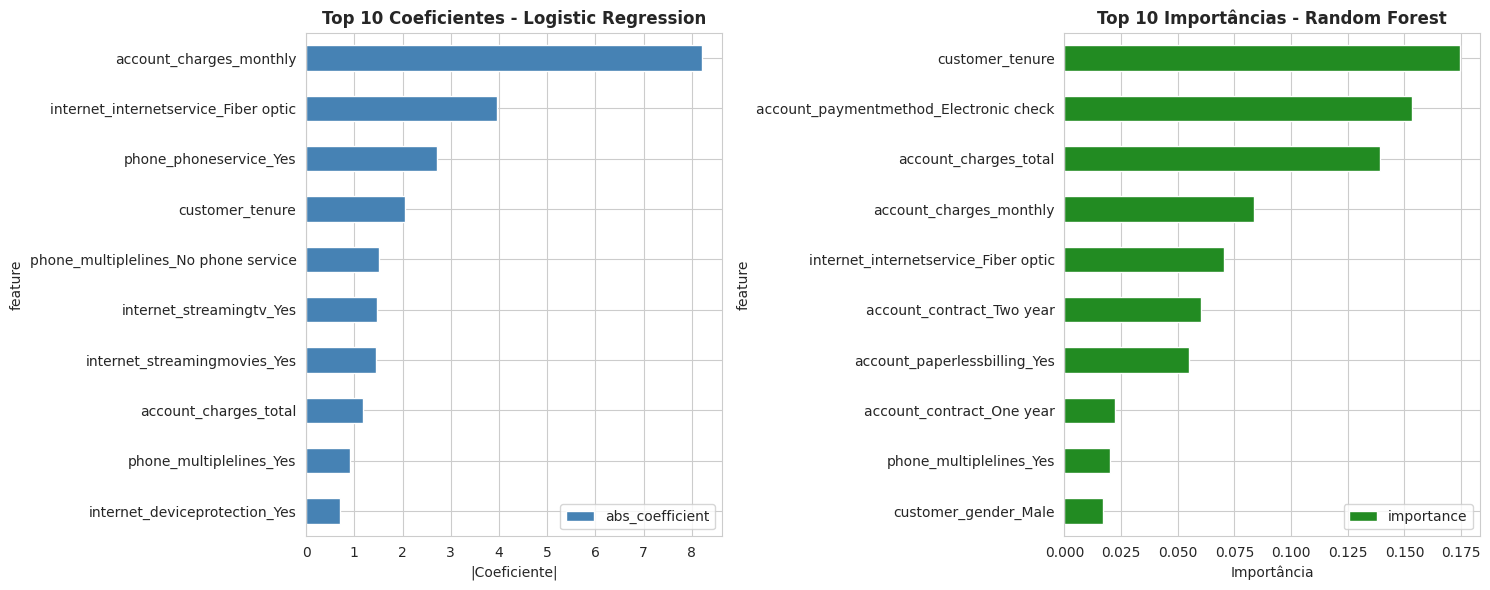

In [7]:
# 6️⃣ ANÁLISE DE IMPORTÂNCIA DAS VARIÁVEIS
print("\n6️⃣ ANÁLISE DE IMPORTÂNCIA DAS VARIÁVEIS:\n")

# LOGISTIC REGRESSION - Coeficientes
print("📌 LOGISTIC REGRESSION - TOP 15 COEFICIENTES:\n")

# Obter nomes das features
feature_names = X_train_scaled.columns if isinstance(X_train_scaled, pd.DataFrame) else [f'f{i}' for i in range(X_train_scaled.shape[1])]

# Coeficientes
coef_lr = lr_model.coef_[0]
coef_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef_lr,
    'abs_coefficient': np.abs(coef_lr)
}).sort_values('abs_coefficient', ascending=False)

print("Top 15 variáveis mais influentes (por magnitude do coeficiente):")
print(coef_importance.head(15).to_string(index=False))

# RANDOM FOREST - Feature Importance
print("\n\n📌 RANDOM FOREST - TOP 15 IMPORTÂNCIAS:\n")

importance_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 variáveis mais importantes (por importância na floresta):")
print(importance_rf.head(15).to_string(index=False))

# Visualizar importâncias
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Logistic Regression
coef_importance.head(10).plot(x='feature', y='abs_coefficient', kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Coeficientes - Logistic Regression', fontsize=12, fontweight='bold')
axes[0].set_xlabel('|Coeficiente|')
axes[0].invert_yaxis()

# Random Forest
importance_rf.head(10).plot(x='feature', y='importance', kind='barh', ax=axes[1], color='forestgreen')
axes[1].set_title('Top 10 Importâncias - Random Forest', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importância')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [8]:
# 7️⃣ SALVAR MODELOS TREINADOS
print("\n7️⃣ SALVANDO MODELOS TREINADOS:\n")

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

# Salvar modelos
joblib.dump(lr_model, models_dir / 'logistic_regression_v1.joblib')
joblib.dump(rf_model, models_dir / 'random_forest_v1.joblib')
joblib.dump(metrics_lr, models_dir / 'metrics_lr_v1.joblib')
joblib.dump(metrics_rf, models_dir / 'metrics_rf_v1.joblib')

print(f"   ✅ Modelos salvos em: {models_dir}")
print(f"   - logistic_regression_v1.joblib")
print(f"   - random_forest_v1.joblib")
print(f"   - metrics_lr_v1.joblib")
print(f"   - metrics_rf_v1.joblib")


7️⃣ SALVANDO MODELOS TREINADOS:

   ✅ Modelos salvos em: ../models
   - logistic_regression_v1.joblib
   - random_forest_v1.joblib
   - metrics_lr_v1.joblib
   - metrics_rf_v1.joblib


In [9]:
# 8️⃣ RESUMO EXECUTIVO
print("\n" + "="*60)
print("📊 RESUMO EXECUTIVO - MODELAGEM".center(60))
print("="*60)

print(f"\n🎯 MODELOS TREINADOS:")
print(f"   1. Logistic Regression")
print(f"      - Acurácia: {metrics_lr['accuracy']:.4f}")
print(f"      - F1-Score: {metrics_lr['f1']:.4f}")
print(f"\n   2. Random Forest")
print(f"      - Acurácia: {metrics_rf['accuracy']:.4f}")
print(f"      - F1-Score: {metrics_rf['f1']:.4f}")

# Qual é o melhor?
if metrics_rf['f1'] > metrics_lr['f1']:
    print(f"\n   🏆 MELHOR MODELO: Random Forest (F1: {metrics_rf['f1']:.4f})")
else:
    print(f"\n   🏆 MELHOR MODELO: Logistic Regression (F1: {metrics_lr['f1']:.4f})")

print(f"\n📌 TOP 5 VARIÁVEIS MAIS IMPORTANTES:")
for i, row in importance_rf.head(5).iterrows():
    print(f"   {i+1}. {row['feature']} (importância: {row['importance']:.4f})")

print(f"\n💾 PRÓXIMOS PASSOS:")
print(f"   - Notebook 04: Avaliação detalhada com múltiplas métricas")
print(f"   - Notebook 05: Relatório final com recomendações estratégicas")

print(f"\n" + "="*60)
print("✅ MODELAGEM CONCLUÍDA COM SUCESSO!".center(60))
print("="*60)


               📊 RESUMO EXECUTIVO - MODELAGEM               

🎯 MODELOS TREINADOS:
   1. Logistic Regression
      - Acurácia: 0.7708
      - F1-Score: 0.5875

   2. Random Forest
      - Acurácia: 0.7779
      - F1-Score: 0.6102

   🏆 MELHOR MODELO: Random Forest (F1: 0.6102)

📌 TOP 5 VARIÁVEIS MAIS IMPORTANTES:
   2. customer_tenure (importância: 0.1746)
   29. account_paymentmethod_Electronic check (importância: 0.1532)
   4. account_charges_total (importância: 0.1394)
   3. account_charges_monthly (importância: 0.0838)
   11. internet_internetservice_Fiber optic (importância: 0.0705)

💾 PRÓXIMOS PASSOS:
   - Notebook 04: Avaliação detalhada com múltiplas métricas
   - Notebook 05: Relatório final com recomendações estratégicas

             ✅ MODELAGEM CONCLUÍDA COM SUCESSO!             
